In [1]:
# %matplotlib widget
import numpy as np
from sim_library.constants import k_eff, dR, m, kb, omega_eg
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq, RR3_adjMDFE_500kHz
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare, plot_bloch_multi
from sim_library.data_io import load_p_dists

In [2]:
def delta_plus(m, delta_D, delta_R, delta_L):
    """delta^+_m: total detuning for an upwards pulse coupling states m, m+1."""
    return delta_D + (2 * m + 1) * delta_R - delta_L
 
def delta_minus(m, delta_D, delta_R, delta_L):
    """delta^-_m: total detuning for a downwards pulse coupling states m, m+1."""
    return delta_D + (2 * m + 1) * delta_R + delta_L
 
def G_plus_step(c0, t, delta_D, delta_R, delta_L, Omega_R, n):
    """
    Apply the G_+ MDFE sequence propagator to the 2-level {n, n+1} subspace,
    assuming c_{n-1}^(0) = c_{n+2}^(0) = 0.
 
    Parameters
    ----------
    c0 : array_like, shape (2,), complex
        Initial amplitudes [c_n^(0), c_{n+1}^(0)].
    t : float
        Total sequence time (as in the G_+(t/tau) expressions).
    delta_D, delta_R, delta_L : float
        Doppler, recoil, and laser detunings (angular frequency units).
    Omega_R : float
        Rabi frequency (Omega_R^-, used throughout this sequence).
    n : int
        Lower index of the {n, n+1} pair (n taken even, as in the derivation).
 
    Returns
    -------
    c : ndarray, shape (2,), complex
        Final amplitudes [c_n, c_{n+1}].
    """
    c_n0, c_np1_0 = c0
 
    # --- c_n:  uses m = n-1 ---
    dm = delta_minus(n - 1, delta_D, delta_R, delta_L)
    dp = delta_plus(n - 1, delta_D, delta_R, delta_L)
    Omega_eff = np.sqrt(Omega_R**2 + dm**2)
    phi = (np.pi / 2) * (Omega_eff / Omega_R)
 
    prefactor_n = np.exp(
        1j * ((n - 1) * (delta_D + (n - 1) * delta_R) + dp / 2) * (2 * np.pi / Omega_R)
    )
    bracket_n = np.cos(phi) + 1j * (dm / Omega_eff) * np.sin(phi)
    term1_n = np.exp(1j * n * (delta_D + n * delta_R) * t / 2) * bracket_n**2
    term2_n = (
        np.exp(1j * ((2*n - 1)*delta_D + (2*n**2 - 2*n + 1)*delta_R - delta_L) * t / 4)
        * (Omega_R**2 / Omega_eff**2)
        * np.sin(phi)**2
    )
    c_n = c_n0 * prefactor_n * (term1_n - term2_n)
 
    # --- c_{n+1}:  uses m = n+1 ---
    dm2 = delta_minus(n + 1, delta_D, delta_R, delta_L)
    dp2 = delta_plus(n + 1, delta_D, delta_R, delta_L)
    Omega_eff2 = np.sqrt(Omega_R**2 + dm2**2)
    phi2 = (np.pi / 2) * (Omega_eff2 / Omega_R)
 
    prefactor_np1 = np.exp(
        1j * ((n + 1) * (delta_D + (n + 1) * delta_R) + dp2 / 2) * (2 * np.pi / Omega_R)
    )
    bracket_np1 = np.cos(phi2) - 1j * (dm2 / Omega_eff2) * np.sin(phi2)
    term1_np1 = (
        np.exp(1j * ((n + 1) * (delta_D + (n + 1) * delta_R) - delta_L) * t / 2)
        * bracket_np1**2
    )
    term2_np1 = (
        np.exp(1j * ((2*n + 3)*delta_D + (2*n**2 + 6*n + 5)*delta_R - delta_L) * t / 4)
        * (Omega_R**2 / Omega_eff2**2)
        * np.sin(phi2)**2
    )
    c_np1 = c_np1_0 * prefactor_np1 * (term1_np1 - term2_np1)
 
    return np.array([c_n, c_np1], dtype=np.complex128)

def G_minus_step(c0, t, delta_D, delta_R, delta_L, Omega_R, n):
    """
    Apply the G_- MDFE sequence propagator to the 2-level {n, n+1} subspace,
    assuming c_{n-1}^(0) = c_{n+2}^(0) = 0.
 
    Same structure as G_plus_step, but the Rabi/mixing-angle terms use
    delta^+_m instead of delta^-_m, and the free-evolution phases inside
    each term are swapped accordingly (see derivation).
 
    Parameters
    ----------
    c0 : array_like, shape (2,), complex
        Initial amplitudes [c_n^(0), c_{n+1}^(0)].
    t : float
        Total sequence time.
    delta_D, delta_R, delta_L : float
        Doppler, recoil, and laser detunings (angular frequency units).
    Omega_R : float
        Rabi frequency (Omega_R^+, used throughout this sequence).
    n : int
        Lower index of the {n, n+1} pair.
 
    Returns
    -------
    c : ndarray, shape (2,), complex
        Final amplitudes [c_n, c_{n+1}].
    """
    c_n0, c_np1_0 = c0
 
    # --- c_n:  uses m = n-1 ---
    dp = delta_plus(n - 1, delta_D, delta_R, delta_L)
    Omega_eff = np.sqrt(Omega_R**2 + dp**2)
    phi = (np.pi / 2) * (Omega_eff / Omega_R)
 
    prefactor_n = np.exp(
        1j * ((n - 1) * (delta_D + (n - 1) * delta_R) + dp / 2) * (2 * np.pi / Omega_R)
    )
    bracket_n = np.cos(phi) + 1j * (dp / Omega_eff) * np.sin(phi)
    term1_n = (
        np.exp(1j * (n * (delta_D + n * delta_R) - delta_L) * t / 2) * bracket_n**2
    )
    term2_n = (
        np.exp(1j * ((2*n - 1)*delta_D + (2*n**2 - 2*n + 1)*delta_R - delta_L) * t / 4)
        * (Omega_R**2 / Omega_eff**2)
        * np.sin(phi)**2
    )
    c_n = c_n0 * prefactor_n * (term1_n - term2_n)
 
    # --- c_{n+1}:  uses m = n+1 ---
    dp2 = delta_plus(n + 1, delta_D, delta_R, delta_L)
    Omega_eff2 = np.sqrt(Omega_R**2 + dp2**2)
    phi2 = (np.pi / 2) * (Omega_eff2 / Omega_R)
 
    prefactor_np1 = np.exp(
        1j * ((n + 1) * (delta_D + (n + 1) * delta_R) + dp2 / 2) * (2 * np.pi / Omega_R)
    )
    bracket_np1 = np.cos(phi2) - 1j * (dp2 / Omega_eff2) * np.sin(phi2)
    term1_np1 = (
        np.exp(1j * (n + 1) * (delta_D + (n + 1) * delta_R) * t / 2) * bracket_np1**2
    )
    term2_np1 = (
        np.exp(1j * ((2*n + 3)*delta_D + (2*n**2 + 6*n + 5)*delta_R - delta_L) * t / 4)
        * (Omega_R**2 / Omega_eff2**2)
        * np.sin(phi2)**2
    )
    c_np1 = c_np1_0 * prefactor_np1 * (term1_np1 - term2_np1)
 
    return np.array([c_n, c_np1], dtype=np.complex128)

def _bracket(exp_arg1, sign, exp_arg2, Omega_R, delta_minus):
    """
    Compute one of the two interference brackets:
 
        exp(i*exp_arg1) * [cos(theta) + sign*i*(delta_minus/D)*sin(theta)]^2
        - exp(i*exp_arg2) * (Omega_R^2 / D^2) * sin(theta)^2
 
    where D = sqrt(Omega_R^2 + delta_minus^2), theta = (pi/2) * D / Omega_R.
 
    sign = +1 reproduces the c_n (lower, index n-1) bracket,
    sign = -1 reproduces the c_{n+1} (upper, index n+1) bracket.
    """
    D = np.sqrt(Omega_R**2 + delta_minus**2)
    theta = (np.pi / 2) * D / Omega_R
    X = np.cos(theta) + sign * 1j * (delta_minus / D) * np.sin(theta)
    term1 = np.exp(1j * exp_arg1) * X**2
    term2 = np.exp(1j * exp_arg2) * (Omega_R**2 / D**2) * np.sin(theta) ** 2
    return term1 - term2
 
 
def delta_phi_G_plus(n, t, Omega_R, delta_D, delta_R, delta_L):
    """
    Relative phase Delta phi^{G+}_{n, n+1}(t):
 
        Delta phi^{G+}_{n,n+1} =
            (delta_D + (2n+1)*delta_R) * (4*pi/Omega_R)
            + arg(bracket_{n+1})
            - arg(bracket_{n-1})
 
    delta^-_{n+1} and delta^-_{n-1} are computed internally via the
    existing delta_minus(m, delta_D, delta_R, delta_L) function.
 
    Parameters
    ----------
    n : int or float
        Momentum-state index.
    t : float or array_like
        Time.
    Omega_R : float
        Rabi frequency.
    delta_D, delta_R, delta_L : float
        Doppler, recoil, and laser detunings (global, n-independent).
 
    Returns
    -------
    float or ndarray
        Delta phi^{G+}_{n,n+1}(t), in radians (wrapped to (-pi, pi] by
        np.angle within each bracket; the leading prefactor term is
        NOT wrapped, since it is an exact closed-form quantity).
    """
    delta_minus_np1 = delta_minus(n + 1, delta_D, delta_R, delta_L)
    delta_minus_nm1 = delta_minus(n - 1, delta_D, delta_R, delta_L)
 
    # Closed-form global-prefactor contribution
    prefactor = (delta_D + (2 * n + 1) * delta_R) * (4 * np.pi / Omega_R)
 
    # Bracket for c_{n+1} (uses index n+1, "-i" sign convention)
    exp_arg1_upper = ((n + 1) * (delta_D + (n + 1) * delta_R) - delta_L) * t / 2
    exp_arg2_upper = ((2 * n + 3) * delta_D
                       + (2 * n**2 + 6 * n + 5) * delta_R
                       - delta_L) * t / 4
    bracket_upper = _bracket(exp_arg1_upper, -1, exp_arg2_upper,
                              Omega_R, delta_minus_np1)
 
    # Bracket for c_n (uses index n-1, "+i" sign convention)
    exp_arg1_lower = n * (delta_D + n * delta_R) * t / 2
    exp_arg2_lower = ((2 * n - 1) * delta_D
                       + (2 * n**2 - 2 * n + 1) * delta_R
                       - delta_L) * t / 4
    bracket_lower = _bracket(exp_arg1_lower, +1, exp_arg2_lower,
                              Omega_R, delta_minus_nm1)
 
    return prefactor + np.angle(bracket_upper) - np.angle(bracket_lower)

In [9]:
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

initial_state = np.array([1,1], dtype=np.complex128)
initial_state = initial_state/ np.linalg.norm(initial_state)

dt = pi/(8*dR)

n= 1

output = G_minus_step(initial_state, dt, delta_D=0, delta_L=0, delta_R=dR, Omega_R=rabi_freq, n=n)

print(output)
print((np.angle(output[1])-np.angle(output[0]))/pi)

[-0.69365477-0.13723276j  0.57200092-0.40851243j]
0.7404188205044729


In [14]:
rabi_freq = 2*pi*5e8
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[8] = 1
initial_state[9] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0.0 # Stationary

Gplus = gen_MDFEdown_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=1)

wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq= Gplus, basis= basis, initial_state=initial_state, d_shift=0)

final = wave_func[-1,:]

print(final[8:10])
print((np.angle(final[9])-np.angle(final[8]))/pi)

[-0.70369514-0.06937685j -0.62345076-0.33363025j]
0.12512350836760772


In [19]:
phase = delta_phi_G_plus(n=0, t=pi/(8*dR), Omega_R=2*pi*5e5, delta_D=0, delta_L=0, delta_R=dR)
print(phase/pi - 0.125)

0.1223927646311748


In [17]:
print(dR*4*pi/(2*pi*5e5)/pi)

0.12350913108435323


### Phase vs rabi freq

#### G+(pi/8)

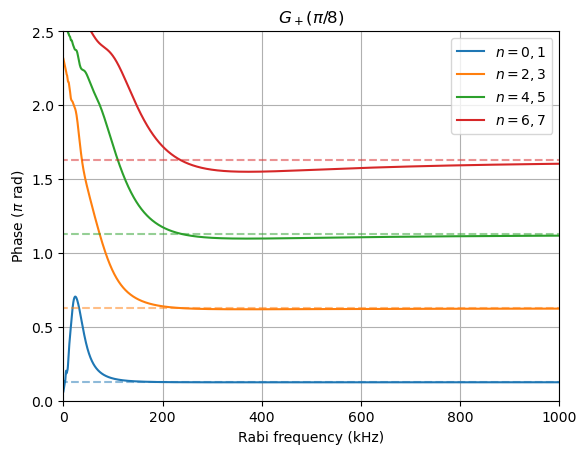

In [31]:
rabi_freq = 2*pi*2e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[8] = 1
initial_state[9] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0.0 # Stationary

rabis = np.linspace(1, 2*pi*5e6,10000)
phases = np.zeros(shape = (len(indices),len(rabis)))


for i, rabi in enumerate(rabis):
    
    rabi_time = 2*pi/rabi
    T = pi/(8*dR) - (4*pi/rabi)

    pulses = PulseSequence()
    pulse1 = DownPulse(laser_det=np.full(n_steps,0), phase=np.full(n_steps,pi/2), rabi_freq = np.full(n_steps,rabi), duration=rabi_time/2)
    free1 = FreeEvolution(laser_det=np.full(n_steps, 0), duration=T/8)
    free2 = FreeEvolution(laser_det=np.full(n_steps, 0), duration=T/4)
    pulses.add_pulses([free1, pulse1, free2, pulse1, free1])

    for j in range(len(indices)):
        # Define initial state vector
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[indices[j]] = 1
        initial_state[indices[j]+1] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

        wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq= pulses, basis= basis, initial_state=initial_state, d_shift=0)

        final = wave_func[-1,:]

        phases[j, i] = (np.angle(final[indices[j]+1])-np.angle(final[indices[j]]))/pi
    



phases = np.unwrap(phases, axis = 1, period = 2)
phases[1:3,:] += 2
phases[3,:] += 4

plt.plot(rabis/(2*pi*1e3), phases.transpose())
plt.plot([-30,3000],[0.125,0.125], ls='--', alpha=0.5, c='tab:blue')
plt.plot([-30,3000],[0.625,0.625], ls='--', alpha=0.5, c='tab:orange')
plt.plot([-30,3000],[1.125,1.125], ls='--', alpha=0.5, c='tab:green')
plt.plot([-30,3000],[1.625,1.625], ls='--', alpha=0.5, c='tab:red')

plt.xlim(0,1000)
plt.ylim(0, 2.5)

plt.ylabel(r'Phase ($\pi$ rad)')
plt.xlabel(r'Rabi frequency (kHz)')

plt.title(r'$G_+(\pi/8)$')
plt.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='upper right')
plt.grid()

#### G+(pi/4)

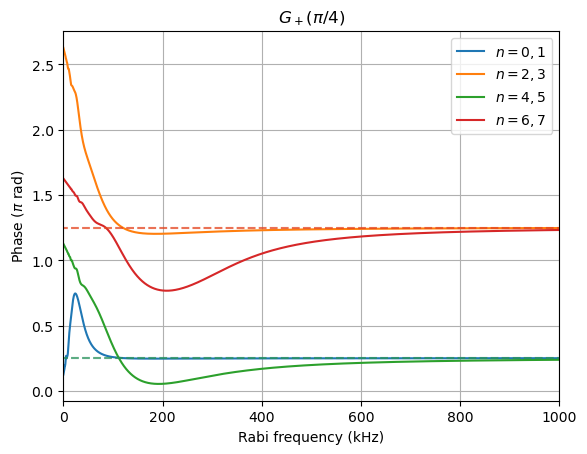

In [46]:
rabi_freq = 2*pi*2e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

# Define initial state vector
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[8] = 1
initial_state[9] = 1
initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

# Set doppler shift
atom_veloc = 0.0 # Stationary

rabis = np.linspace(1, 2*pi*5e6,10000)
phases = np.zeros(shape = (len(indices),len(rabis)))


for i, rabi in enumerate(rabis):
    
    rabi_time = 2*pi/rabi
    T = pi/(4*dR) - (4*pi/rabi)

    pulses = PulseSequence()
    pulse1 = DownPulse(laser_det=np.full(n_steps,0), phase=np.full(n_steps,pi/2), rabi_freq = np.full(n_steps,rabi), duration=rabi_time/2)
    free1 = FreeEvolution(laser_det=np.full(n_steps, 0), duration=T/8)
    free2 = FreeEvolution(laser_det=np.full(n_steps, 0), duration=T/4)
    pulses.add_pulses([free1, pulse1, free2, pulse1, free1])

    for j in range(len(indices)):
        # Define initial state vector
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[indices[j]] = 1
        initial_state[indices[j]+1] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

        wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq= pulses, basis= basis, initial_state=initial_state, d_shift=0)

        final = wave_func[-1,:]

        phases[j, i] = (np.angle(final[indices[j]+1])-np.angle(final[indices[j]]))/pi
    



phases = np.unwrap(phases, axis = 1, period = 2)
phases[1,:] += 4
phases[2:4,:] += 2

plt.plot(rabis/(2*pi*1e3), phases.transpose())
plt.plot([-30,3000],[0.25,0.25], ls='--', alpha=0.5, c='tab:blue')
plt.plot([-30,3000],[1.25,1.25], ls='--', alpha=0.5, c='tab:orange')
plt.plot([-30,3000],[0.25,0.25], ls='--', alpha=0.5, c='tab:green')
plt.plot([-30,3000],[1.25,1.25], ls='--', alpha=0.5, c='tab:red')

plt.xlim(0,1000)
# plt.ylim(0, 2.5)

plt.ylabel(r'Phase ($\pi$ rad)')
plt.xlabel(r'Rabi frequency (kHz)')

plt.title(r'$G_+(\pi/4)$')
plt.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='upper right')
plt.grid()